# Section A: LLM Foundations & Hugging Face

### Install & Load Model

In [75]:
!pip install transformers torch --quiet

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



### Load DistilGPT-2 and Generate 3 Text Variations

In [76]:
from transformers import pipeline
generator = pipeline("text-generation", model="distilgpt2") #<- this model was generating bad outputs
prompt = "AI is transforming industries by"
outputs = generator(prompt, max_length=40, num_return_sequences=3)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In [77]:
for i, output in enumerate(outputs, 1):
    clean_text = output['generated_text'].replace("\n", " ")
    print(f"Output {i}: {clean_text}")

Output 1: AI is transforming industries by bringing companies to the table over a number of different technologies and technologies.                     
Output 2: AI is transforming industries by harnessing innovation for what we call the consumer, who also have tremendous potential for growth and economic growth.
Output 3: AI is transforming industries by adopting a more traditional approach for the management of consumer and retail businesses. Such enterprises also invest heavily in their automation systems, for example adding new features of automation automation systems such as


### Tokenisation Demo

In [78]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilgpt2")

sentence = "LLMs are powerful tools for natural language understanding."

tokens = tokenizer.tokenize(sentence)
token_ids = tokenizer.convert_tokens_to_ids(tokens)
sequence_length = len(token_ids)

print("Tokens:", tokens)
print("Token IDs:", token_ids)
print("Sequence Length:", sequence_length)

Tokens: ['LL', 'Ms', 'Ġare', 'Ġpowerful', 'Ġtools', 'Ġfor', 'Ġnatural', 'Ġlanguage', 'Ġunderstanding', '.']
Token IDs: [3069, 10128, 389, 3665, 4899, 329, 3288, 3303, 4547, 13]
Sequence Length: 10


### CONCLUSION
Tokenization breaks sentences into smaller units called tokens. These tokens are mapped to token IDs that the model uses numerically.
The sequence length shows how many tokens are passed into the model for processing.

# SECTION B — PROMPT ENGINEERING

### Create 3 Prompts

In [82]:
summarisation_prompt = "Strictly answer in 30 words: Artificial intelligence is changing healthcare, How?"
qa_prompt = "Strictly answer in 30 words: Who invented Python and in which year?"
creative_prompt = "Strictly answer in 30 words: Write a 4-line poem about AI and humanity."

In [83]:
prompts = [summarisation_prompt, qa_prompt, creative_prompt]
print(f" The list promts consists of: {prompts}")

 The list promts consists of: ['Strictly answer in 30 words: Artificial intelligence is changing healthcare, How?', 'Strictly answer in 30 words: Who invented Python and in which year?', 'Strictly answer in 30 words: Write a 4-line poem about AI and humanity.']


In [86]:
''' for p in prompts:
    print("PROMPT:", p)
    print("RESPONSE:", generator(p, max_length=160, num_return_sequences=1)[0]['generated_text'],"\n") '''

for i in range(len(prompts)):
    if i == 0:
        print()
        print("PROMPT:", prompts[i])
        print("RESPONSE:", generator(prompts[i], max_length=130, num_return_sequences=1)[0]['generated_text'],"\n")
    else:
        print("PROMPT:", prompts[i])
        print("RESPONSE:", generator(prompts[i], max_length=160, num_return_sequences=1)[0]['generated_text'], "\n")
    

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.

PROMPT: Strictly answer in 30 words: Artificial intelligence is changing healthcare, How?
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
RESPONSE: Strictly answer in 30 words: Artificial intelligence is changing healthcare, How?




Now the main problem I hear is the number of "hints" that are not really coming to the United States as of the end of this year. Here are some of the things you should think about when trying to take your healthcare situation to the next level in your life:

Health Care — When a healthcare provider gets the wrong information or the right type of healthcare, then they can be just a little too big or too slow.
You may be thinking that healthcare is growing, because they need more providers right now, and they 

PROMPT: Strictly answer in 30 words: Who invented Python and in which year?
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
RESPON

### USING WEB REQUEST AND API CALL

In [9]:
summarisation_prompt = "Strictly answer in 30 words: Artificial intelligence is changing healthcare, How?"
qa_prompt = "Strictly answer in 30 words: Who invented Python and in which year?"
creative_prompt = "Strictly answer in 30 words: Write a 4-line poem about AI and humanity."

In [101]:
!pip install requests --quiet

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



In [1]:
!pip install "huggingface_hub>=0.26.0" --quiet


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [102]:
import os
os.environ["HF_TOKEN"] = "your_huggingface_token_here"

In [2]:
import os
import requests
import json
from huggingface_hub import InferenceClient

In [14]:
MODEL_ID = "Qwen/Qwen3-4B-Instruct-2507"

os.environ["HF_TOKEN"] = "your_huggingface_token_here"  # make sure this is set correctly
HF_TOKEN = os.environ["HF_TOKEN"]

client = InferenceClient(
    model=MODEL_ID,
    token=HF_TOKEN,
)

In [15]:
def hf_generate(prompt,
                max_tokens=80,
                temperature=0.7,
                top_p=0.9):
    """
    Generate text using the conversational (chat) endpoint
    via InferenceClient.chat_completion.
    """
    completion = client.chat_completion(
        messages=[
            {"role": "user", "content": prompt}
        ],
        max_tokens=max_tokens,     # similar idea to max_new_tokens
        temperature=temperature,   # randomness
        top_p=top_p,               # nucleus sampling
    )
    
    # Take the text of the first choice
    return completion.choices[0].message["content"]

'''def hf_generate(prompt,
                max_new_tokens=80,
                temperature=0.7,
                top_p=0.9,
                do_sample=True,
                return_full_text=False):
    payload = {
        "inputs": prompt,
        "parameters": {
            "max_new_tokens": max_new_tokens,
            "temperature": temperature,
            "top_p": top_p,
            "do_sample": do_sample,
            "return_full_text": return_full_text
        }
    }
    
    response = requests.post(API_URL, headers=headers, json=payload)
    response.raise_for_status()  # raise error if bad status
    
    data = response.json()
    # HF returns a list of dicts: [{"generated_text": "..."}]
    return data[0]["generated_text"]
    '''

'def hf_generate(prompt,\n                max_new_tokens=80,\n                temperature=0.7,\n                top_p=0.9,\n                do_sample=True,\n                return_full_text=False):\n    payload = {\n        "inputs": prompt,\n        "parameters": {\n            "max_new_tokens": max_new_tokens,\n            "temperature": temperature,\n            "top_p": top_p,\n            "do_sample": do_sample,\n            "return_full_text": return_full_text\n        }\n    }\n    \n    response = requests.post(API_URL, headers=headers, json=payload)\n    response.raise_for_status()  # raise error if bad status\n    \n    data = response.json()\n    # HF returns a list of dicts: [{"generated_text": "..."}]\n    return data[0]["generated_text"]\n    '

In [16]:
prompts = [
    ("Summarisation", summarisation_prompt),
    ("Q&A", qa_prompt),
    ("Creative Poem", creative_prompt),
]

for label, prompt in prompts:
    print("=" * 60)
    print(f"TASK: {label}")
    print("-" * 60)
    output = hf_generate(prompt, max_tokens=80, temperature=0.7, top_p=0.9)
    print(output.strip(), "\n")

TASK: Summarisation
------------------------------------------------------------
AI enhances diagnostics, personalizes treatment, streamlines operations, and improves drug discovery through data analysis, predictive modeling, and automation, increasing efficiency, accuracy, and access to care. 

TASK: Q&A
------------------------------------------------------------
Guido van Rossum invented Python in 1991. 

TASK: Creative Poem
------------------------------------------------------------
AI mirrors minds, learns from human dreams,  
Yet lacks soul, emotion, or true sense.  
We guide its thoughts, it serves our needs—  
Together, we shape tomorrow’s chance. 



### CONCLUSION
When rephrasing prompts, I observed that small wording changes significantly affected output clarity and relevance. Specific instructions such as setting a word limit or defining output format helped guide the model toward better responses. The summarisation task produced more focused results when a word constraint was included. For factual Q&A, vague prompts produced incomplete or incorrect answers, while clear questions improved accuracy. Creative prompts resulted in diverse outputs depending on tone and description detail. Overall, prompt engineering improved control, coherence, and usefulness of responses. This shows that LLMs rely heavily on input phrasing and context clarity rather than true understanding. Well-structured prompts are essential for getting reliable and relevant outputs from models like Qwen3-4B-Instruct-2507. THE respomse from using model like DISTIL-GPT2 was bad and irrelevant.

# SECTION C — GENSIM EMBEDDINGS

### Load GloVe Word Vectors for Word Embeddings

In [1]:
!pip install gensim --quiet


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [0]:
import gensim.downloader as api

model = api.load("glove-wiki-gigaword-50")

[=================================================-] 99.9% 65.9/66.0MB downloaded

### Word Embeddings

In [3]:
words = ["king", "queen", "diamond"]

for word in words:
    print(f"\nWORD: {word}")
    print("First 10 vector values:", model[word][:10])
    print("Top 5 similar words:")
    for sim in model.most_similar(word, topn=5):
        print(sim)


WORD: king
First 10 vector values: [ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012 ]
Top 5 similar words:
('prince', 0.8236179351806641)
('queen', 0.7839043140411377)
('ii', 0.7746230363845825)
('emperor', 0.7736247777938843)
('son', 0.766719400882721)

WORD: queen
First 10 vector values: [ 0.37854   1.8233   -1.2648   -0.1043    0.35829   0.60029  -0.17538
  0.83767  -0.056798 -0.75795 ]
Top 5 similar words:
('princess', 0.8515166640281677)
('lady', 0.805060863494873)
('elizabeth', 0.787304162979126)
('king', 0.7839043140411377)
('prince', 0.7821861505508423)

WORD: diamond
First 10 vector values: [-0.4958   0.78421 -0.606    1.3967   0.28888 -0.2058  -0.10745 -0.33252
  1.3608   0.15091]
Top 5 similar words:
('gold', 0.7714747190475464)
('diamonds', 0.7662666440010071)
('gem', 0.7375268936157227)
('silver', 0.72101891040802)
('jewel', 0.7102220058441162)


### Sentence Embeddings & Similarity Matrix

In [4]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

sentences = [
    "AI improves healthcare diagnosis",
    "Machine learning supports doctors",
    "Diamonds are used in jewellery",
    "Gold and silver are precious metals",
    "AI is transforming businesses"
]

def sent_vector(sentence):
    words = sentence.lower().split()
    valid = [model[word] for word in words if word in model]
    return np.mean(valid, axis=0)

vectors = np.array([sent_vector(s) for s in sentences])

similarity = cosine_similarity(vectors)

In [5]:
print(similarity)

[[1.         0.7093215  0.25594014 0.23688862 0.64893836]
 [0.7093215  0.99999994 0.5972236  0.45121273 0.7659094 ]
 [0.25594014 0.5972236  1.         0.8809316  0.6871816 ]
 [0.23688862 0.45121273 0.8809316  0.99999994 0.6039631 ]
 [0.64893836 0.7659094  0.6871816  0.6039631  1.0000001 ]]


In [6]:
import pandas as pd

df = pd.DataFrame(similarity, index=sentences, columns=sentences)

In [7]:
print(df)

                                     AI improves healthcare diagnosis  \
AI improves healthcare diagnosis                             1.000000   
Machine learning supports doctors                            0.709321   
Diamonds are used in jewellery                               0.255940   
Gold and silver are precious metals                          0.236889   
AI is transforming businesses                                0.648938   

                                     Machine learning supports doctors  \
AI improves healthcare diagnosis                              0.709321   
Machine learning supports doctors                             1.000000   
Diamonds are used in jewellery                                0.597224   
Gold and silver are precious metals                           0.451213   
AI is transforming businesses                                 0.765909   

                                     Diamonds are used in jewellery  \
AI improves healthcare diagnosis             

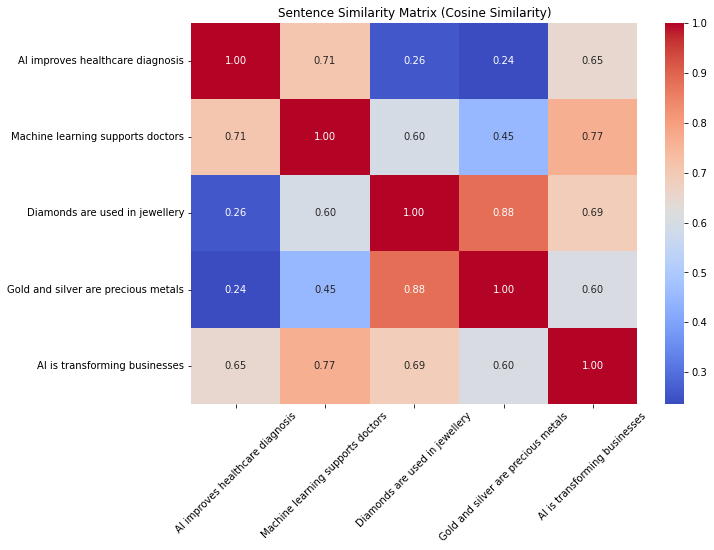

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Sentence Similarity Matrix (Cosine Similarity)")
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.show()

### CONCLUSION
The similarity matrix shows high similarity between AI-related sentences and lower similarity between technology and jewellery topics. This confirms embeddings capture semantic meaning effectively. Closer scores indicate concept overlap and shared vocabulary.

# SECTION D - APPLICATION DEMO

In [13]:
from transformers import pipeline

### Sentiment Classification Demo

In [15]:
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

sentiment_text = "The new product launch was a success, but some customers complained about the slow delivery time."

sentiment_result = sentiment_analyzer(sentiment_text)
print("Input text:\n", sentiment_text, "\n")
print("Sentiment result:\n", sentiment_result)

Input text:
 The new product launch was a success, but some customers complained about the slow delivery time. 

Sentiment result:
 [{'label': 'NEGATIVE', 'score': 0.9982717037200928}]


### Summarisation Demo

In [17]:
summarizer = pipeline(
    "summarization",
    model="facebook/bart-large-cnn"
)

long_text = """
Our company has been investing heavily in artificial intelligence to automate customer support,
optimise supply chains, and personalise marketing campaigns. These initiatives have reduced operational
costs, improved response times, and increased overall customer satisfaction across multiple regions.
"""

summary = summarizer(
    long_text,
    max_length=40,
    min_length=15,
    do_sample=False
)

print("Original text:\n", long_text, "\n")
print("Summary:\n", summary[0]["summary_text"])

Original text:
 
Our company has been investing heavily in artificial intelligence to automate customer support,
optimise supply chains, and personalise marketing campaigns. These initiatives have reduced operational
costs, improved response times, and increased overall customer satisfaction across multiple regions.
 

Summary:
 Our company has been investing heavily in artificial intelligence to automate customer support,optimise supply chains, and personalise marketing campaigns. These initiatives have reduced operationalcosts, improved response times,


### Translation Demo ( English => French example )

In [19]:
translator = pipeline(
    "translation",
    model="Helsinki-NLP/opus-mt-en-fr"
)

translation_input = "Artificial intelligence is helping businesses make faster and more accurate decisions."

translation = translator(translation_input)

print("Original (EN):\n", translation_input, "\n")
print("Translated (FR):\n", translation[0]["translation_text"])

Original (EN):
 Artificial intelligence is helping businesses make faster and more accurate decisions. 

Translated (FR):
 L'intelligence artificielle aide les entreprises à prendre des décisions plus rapides et plus précises.


### CONCLUSION
In this section, I explored three transformer applications: sentiment analysis, summarisation, and translation. Sentiment analysis can automatically classify customer reviews or social media posts as positive or negative, helping businesses monitor brand perception. Summarisation is useful for condensing long reports, emails, or support tickets into short highlights for faster decision-making by managers. Translation enables organisations to communicate with international customers and partners without needing a large team of human translators. Together, these applications show how transformer models can streamline workflows, reduce manual effort, and support data-driven decisions in modern business environments.